#### This notebook plots a prescribed graph and sonifies the data

The data is sonified here with this method:
1. Mass rate (for each edge) at each timestep is computed
2. A space-time data matrix computed as follows:
    * For each active edge going from $z_i$ to $z_j$ with mass rate $\dot{m}_{ij} > 0$, assign $\dot{m}_{ij}$ to $(z_i, z_j)$
    * For a sample depth $z$, we associate a mass rate equal to $\sum \dot{m}_{ij}$ that cut across depth $z$
    * For a uniform grid of $z$ samples, we have a total mass rate $\dot{m}(z, t)$
3. The space-time data are divided into the top third of $(0, 40~\mathrm{km})$, the middle third, and the bottom third.
4. Each third in space is associated with a frequency (notes C, E, G)
5. The sum of total mass rate in each third in space (equal to the average mass rate times the number of samples in each third) is computed as a raw amplitude $A_1(t)$, $A_2(t)$, and $A_3(t)$
    * For stereo sound, each mass rate is associated with the normalized horizontal position $x \in [0, 1]$, and the weights $1-x$ and $x$ are used to ``split" the mass rate between left and right channels
6. The amplitude is interpolated to a playback time vector. The amplitude is used as an envelope for a sine with frequency several times higher than the reciprocal of the simulation timestep
7. The three amplitudes are weighed together arbitrarily and then remapped to the .wav range (-32768, 32767).
    * Higher weights are put on shallower activity

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx

import cnetwork

In [ ]:
import driver

t_vec = np.linspace(0, 2e11*10, 4000*30)

# Run may be skipped if the file "runA01.npz" exists
if False:
  packA1 = driver.run(
    mass_in_rate=4.0e2,
    fig_name=f"runA01.png", npz_filename=f"runA01.npz",
    dpdx_crit=5e2, Nr=20,
    t_vec=t_vec, t_d_min=1e9, t_d_max=1e15)

In [4]:
# Read q_out values back in from npz file (large)
inread = np.load("runA01.npz")
q_out = inread["q_out"]

# Unpack and plot
m_erupted_out = inread["m_erupted_out"]
m_hist = inread["m_hist"]
p = inread["p"]
u = inread["u"]

In [5]:
# Regenerate global_sys object
global_sys = driver.run(
  mass_in_rate=4.0e2,
  fig_name=f"__.png", npz_filename=f"__.npz",
  dpdx_crit=5e2, Nr=20,
  t_vec=t_vec, t_d_min=1e9, t_d_max=1e15, return_object_only=True)

In [6]:
# %pip install sounddevice --user

In [ ]:
res_z = 1000
z_sampler = np.linspace(-40000, 0, res_z)[:, np.newaxis]

def box_fn(a, b, z):
  ''' Box function that fills in (a, b) with value z '''
  return np.where((z_sampler >= a) & (z_sampler <= b), z, 0.0)

In [ ]:
box_cars = []
# Pick the indices of data to sonify (//100 here means take 1% of the data length)
index_target = np.arange(0, q_out.shape[0]//100, 1)
for i in index_target:
  m_rates = global_sys.mass_rates(q_out[i,:], return_format="tups")
  z_min = np.array([np.minimum(global_sys.nodes[tup[0]].z, global_sys.nodes[tup[1]].z) for tup in m_rates])
  z_max = np.array([np.maximum(global_sys.nodes[tup[0]].z, global_sys.nodes[tup[1]].z) for tup in m_rates])
  x_mid = np.array([0.5 * (global_sys.nodes[tup[0]].x + global_sys.nodes[tup[1]].x) for tup in m_rates])
  rate = np.array([tup[2] for tup in m_rates])
  box_cars.append((box_fn(z_min, z_max, rate), x_mid,))

In [9]:
t_sampled = t_vec[index_target]

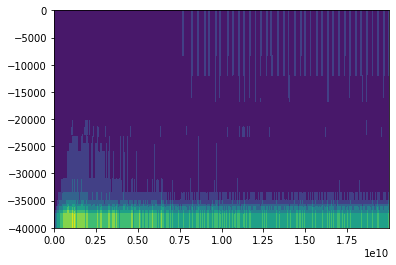

In [22]:
# Sum the boxcars at each time index to obtain datagram
mg_t, mg_z = np.meshgrid(t_sampled, z_sampler)
# Mono audio
mono_z_data = np.array([entry[0].sum(axis=1) for entry in box_cars]).T
plt.contourf(mg_t, mg_z, mono_z_data)

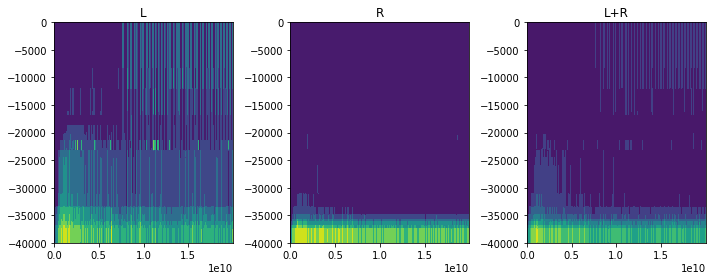

In [71]:
def L_balance(x):
  ''' Weight of L channel == 1 - weight of R channel '''
  x_scale = 40000
  return (x - (-x_scale / 2))/x_scale

stereo_L = np.array([(box_car[0] * L_balance(box_car[1])).sum(axis=1) for box_car in box_cars]).T
stereo_R = np.array([(box_car[0] * (1 - L_balance(box_car[1]))).sum(axis=1) for box_car in box_cars]).T

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.contourf(mg_t, mg_z, stereo_L)
plt.title('L')
plt.subplot(1,3,2)
plt.contourf(mg_t, mg_z, stereo_R)
plt.title('R')
plt.subplot(1,3,3)
plt.contourf(mg_t, mg_z, stereo_L + stereo_R)
plt.title('L+R')
plt.tight_layout()

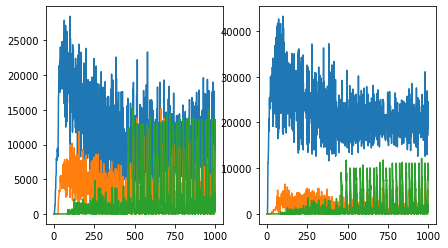

In [64]:
# N-channel mixing:
# Group deep, middle and shallow data and sum
# Modulate envelope for each pitch using data
lowL = stereo_L[:333,:1000].mean(axis=0)
medL = stereo_L[333:666,:1000].mean(axis=0)
highL = stereo_L[666:999,:1000].mean(axis=0)
lowR = stereo_R[:333,:1000].mean(axis=0)
medR = stereo_R[333:666,:1000].mean(axis=0)
highR = stereo_R[666:999,:1000].mean(axis=0)
plt.figure(figsize=(7,4))
plt.subplot(1,2,1)
plt.plot(lowL)
plt.plot(medL)
plt.plot(highL)
plt.subplot(1,2,2)
plt.plot(lowR)
plt.plot(medR)
plt.plot(highR)

In [ ]:
import numpy as np
import sounddevice as sd
import scipy.interpolate

sample_rate:int = 44100
# Target audio band
freq_lims = (130.81, 196)
# Set dt for data change (in terms of audio frequency)
dt = 5/freq_lims[0]

# Expand data to timeline for envelope
t_dat = dt * np.arange(lowL.size)
audio_duration = t_dat.max()

# Time samples
t_sound = np.linspace(0, audio_duration, int(sample_rate *audio_duration), False)

def enveloped_data(data, freq=400, relative_volume=1.0, amplitude_only=False):
  # Compute amplitude envelope by interpolating data to sample itimes
  amplitude = scipy.interpolate.pchip(t_dat, data)(t_sound) / np.abs(data).max()
  phase_component = np.sin(2 * np.pi * freq * t_sound)
  if amplitude_only:
    return amplitude
  else:
    return relative_volume * amplitude * phase_component

def scale_to_int16(total_wav):
  ''' Mix channels without clipping '''
  return (32767 * total_wav / np.abs(total_wav).max()).astype(np.int16)


# def pulse(freq:float, pulse_duration:float, sample_rate:int=44100):
#   ''' Return unit amplitude pulse, pure frequency '''
#   z = 32767 * np.sin(2 * np.pi * freq * t)
#   return z.astype(np.int16)
# sd.play(pulse(800, 0.5) + pulse(800, 0.5))
# sd.play(pulse(800, 0.5) + pulse(800, 0.5))
# sd.wait()


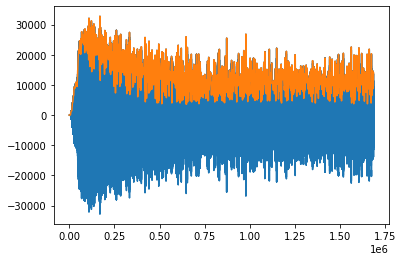

In [ ]:
# Plot bit value of low L for example
plt.plot(scale_to_int16(enveloped_data(lowL, freq=800)))
amp = scale_to_int16(enveloped_data(lowL, freq=800, amplitude_only=True))
plt.plot(amp)

In [69]:
L_data = scale_to_int16(
  enveloped_data(lowL, freq=130.81, relative_volume=1.0)
  + enveloped_data(medL, freq=164.81, relative_volume=2.0)
  + enveloped_data(highL, freq=196.00, relative_volume=4.0)
)
R_data = scale_to_int16(
  enveloped_data(lowR, freq=130.81, relative_volume=1.0)
  + enveloped_data(medR, freq=164.81, relative_volume=2.0)
  + enveloped_data(highR, freq=196.00, relative_volume=4.0)
)

stereo_data = np.column_stack((L_data, R_data))

sd.play(stereo_data)
sd.wait()


In [ ]:
# %pip install soundfile


   ---------------------------------------- 1.0/1.0 MB 3.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import soundfile as sf
# Export sound file
sf.write("stereo_sound.wav", stereo_data, 44100)